# Neural Network Optimizers — From Math to Code

---

## What is an Optimizer?

Training a neural network means finding weights **W** that minimize a loss function **L(W)**.
The loss surface is a high-dimensional, non-convex landscape. An optimizer is the algorithm that navigates this surface.

All gradient-based optimizers share one idea: **follow the gradient downhill**, but they differ in *how they scale the step*, *whether they remember the past*, and *how they treat each parameter independently*.

---

## 1. SGD — Stochastic Gradient Descent

### Math intuition

The simplest update rule:

```
W ← W - η · ∇L(W)
```

- `η` is the learning rate — a fixed scalar.
- `∇L(W)` is the gradient of the loss w.r.t. weights, computed on a mini-batch.

**Why "stochastic"?**  
Using a random mini-batch introduces noise into the gradient estimate. This noise is actually helpful: it prevents the optimizer from settling into sharp minima (which generalise poorly) and helps escape shallow local minima.

**The core problem with vanilla SGD:**
- Ravines: loss surfaces often look like elongated valleys. The gradient points steeply across the narrow dimension and shallowly along the long dimension. SGD oscillates across the ravine while barely moving along it. Convergence is slow.
- Same learning rate for all parameters, regardless of how frequently or rarely they are updated.
- Sensitive to saddle points — gradients are near-zero, so the optimizer stalls.

**When to use:** Simple problems, very large datasets, when you want maximum control and can tune `η` manually. Also effective with careful learning rate scheduling.

**Drawbacks:**
- Oscillations in ravines
- No per-parameter adaptation
- Requires careful LR tuning
- Slow through saddle points

---

## 2. SGD with Momentum

### Math intuition

Inspired by physics: a ball rolling downhill accumulates velocity. We maintain a **velocity vector v** that is an exponentially decaying average of past gradients:

```
v ← β·v + (1-β)·∇L(W)      # accumulate velocity
W ← W - η·v
```

Some formulations (PyTorch default) omit the `(1-β)` scaling:
```
v ← β·v + ∇L(W)
W ← W - η·v
```

Both are equivalent up to an effective LR rescaling.

**Why does this help?**  
- In a consistent gradient direction (the long axis of the ravine), `v` accumulates and accelerates.
- In an oscillating direction (across the ravine), positive and negative gradients cancel, dampening oscillations.
- `β ≈ 0.9` means the effective window is `1/(1-β) = 10` gradient steps.

**Nesterov variant:** Instead of computing the gradient at the *current* position, compute it at the *anticipated* position `W - η·β·v`. This is a "lookahead" that corrects the update before it overshoots:
```
v ← β·v + ∇L(W - η·β·v)
W ← W - η·v
```

**When to use:** A strong default for CNNs with a tuned LR schedule (e.g., cosine annealing). Often beats Adam on image classification when tuned.

**Drawbacks:**
- Still a global learning rate `η`
- Momentum can overshoot if `β` is too large
- Adds one hyperparameter `β`

---

## 3. AdaGrad — Adaptive Gradient

### Math intuition

Idea: parameters that receive large gradients frequently should have their LR *reduced*; parameters that rarely get updated (sparse features, embeddings) should have their LR *increased*.

Maintain a **sum of squared gradients** G for each parameter:

```
G ← G + ∇L²           # element-wise square, accumulated
W ← W - (η / √(G + ε)) · ∇L
```

**Why divide by √G?**  
- If `∇L` has been consistently large (G is large), the effective LR shrinks → small step.
- If `∇L` has been small (G is small), the effective LR stays large → bigger step.
- `ε` (typically 1e-8) prevents division by zero.

The effective learning rate for parameter `i` at step `t` is:
```
η_i(t) = η / √(G_i(t))
```

**The fatal flaw:** G only grows — it is a *cumulative* sum that never forgets. After many steps, G → ∞ for all parameters, and the effective LR → 0. Training halts prematurely. Works well in shallow models or NLP with sparse features, but dies in deep networks.

**When to use:** NLP tasks with sparse inputs (word embeddings), shallow models, tasks where you expect early convergence.

**Drawbacks:**
- Monotonically decreasing LR — learning can stop too early
- Accumulates *all* past gradients equally — no forgetting

---

## 4. RMSProp — Root Mean Squared Propagation

### Math intuition

Geoffrey Hinton's fix for AdaGrad's dying LR: replace the cumulative sum with an **exponentially decaying average** of squared gradients:

```
v ← ρ·v + (1-ρ)·∇L²        # running average of squared gradients
W ← W - (η / √(v + ε)) · ∇L
```

**Key difference from AdaGrad:**  
`v` is a *moving average* — it forgets old gradients exponentially. The denominator stays bounded and reflects recent gradient magnitudes, not the full history. This keeps the effective LR alive throughout training.

**Geometric intuition:**  
`√v` estimates the RMS (root mean square) of recent gradients for each parameter. Dividing by this normalises the step size to be approximately 1 standard deviation of the gradient — a natural unit of step size.

`ρ ≈ 0.9` (or 0.99 for noisy gradients) controls the "memory" window: `1/(1-ρ) = 10` recent steps.

**When to use:** RNNs, LSTMs, online learning, noisy gradient settings. Was Hinton's go-to for RNNs before Adam.

**Drawbacks:**
- No momentum term (gradients can still oscillate)
- Sensitive to `η` — not fully adaptive
- `ρ` is a new hyperparameter

---

## 5. Adam — Adaptive Moment Estimation

### Math intuition

Adam combines **Momentum** (first moment = mean of gradients) with **RMSProp** (second moment = mean of squared gradients):

```
m ← β₁·m + (1-β₁)·∇L           # first moment (mean)
v ← β₂·v + (1-β₂)·∇L²          # second moment (uncentered variance)
```

**Bias correction** — at the start of training, m and v are initialised to 0. For the first few steps they are heavily biased toward zero. We correct this:

```
m̂ = m / (1 - β₁ᵗ)              # bias-corrected first moment
v̂ = v / (1 - β₂ᵗ)              # bias-corrected second moment
```

Why does this work? At step t=1: `m = (1-β₁)·g`. Without correction, `m̂ = (1-β₁)·g` instead of `g`. Dividing by `(1-β₁¹)` recovers the true estimate. As t→∞, `β₁ᵗ → 0` and the correction vanishes.

**Final update:**
```
W ← W - η · m̂ / (√v̂ + ε)
```

**Intuition of the ratio m̂/√v̂:**  
- `m̂` is the signal direction (where to go)
- `√v̂` is the noise/scale (how uncertain we are about each dimension)
- The ratio normalises the step by per-parameter gradient volatility → large effective steps where the surface is smooth, small steps where it is chaotic
- Effective step size is always bounded near `η` (when `m̂ ≈ √v̂`)

**Defaults:** β₁=0.9, β₂=0.999, ε=1e-8

**When to use:** Default choice for most tasks — NLP (Transformers), GANs, VAEs, reinforcement learning. Robust to LR choice.

**Drawbacks:**
- May converge to sharp minima that generalise worse than SGD+Momentum solutions
- Weight decay is **not** L2 regularisation in Adam (see AdamW)
- Can diverge in some settings (AMSGrad was proposed as a fix)
- Higher memory: stores m and v for every parameter (2× SGD)

---

## 6. AdamW — Adam with Decoupled Weight Decay

### Math intuition

In standard Adam, L2 regularisation is typically implemented by adding `λW` to the gradient before the update. This is mathematically *not* the same as weight decay.

In vanilla Adam:
```
∇L_reg = ∇L + λW
m ← β₁·m + (1-β₁)·(∇L + λW)     # L2 reg goes into the moment estimates
```
The adaptive scaling `1/√v̂` also scales the regularisation term, which weakens it for parameters with high gradient variance. Large-gradient parameters get *less* regularisation than intended.

AdamW fixes this by applying weight decay **directly and separately** from the gradient update:
```
W ← W - η · [m̂ / (√v̂ + ε)] - η·λ·W
```

The `λW` term is decoupled — it is not passed through the adaptive scaling. Every parameter decays toward zero at a rate `η·λ` regardless of gradient history.

**When to use:** Transformers (BERT, GPT), any model where you want effective regularisation. Now the default in HuggingFace, PyTorch Lightning, etc.

**Drawbacks:**
- Same memory cost as Adam
- Adds `λ` (weight decay) as a hyperparameter

---

## 7. Nadam — Nesterov + Adam

### Math intuition

Nadam replaces Adam's momentum term with Nesterov momentum. Recall Nesterov computes the gradient at the *lookahead* position. In the Adam framework, we can implement this by substituting the *next* momentum estimate into the update rather than the current one:

```
m̂_nadam = β₁·m̂ + (1-β₁)·∇L / (1-β₁ᵗ)     # incorporates next-step momentum
W ← W - η · m̂_nadam / (√v̂ + ε)
```

This is a single-line change from Adam but provides the lookahead correction, which makes the update more informed about the next gradient direction.

**When to use:** When Adam is already working well and you want marginal improvement — often seen in RNNs and some NLP tasks.

**Drawbacks:**
- Marginal benefit over Adam in practice
- Slightly more complex to implement correctly
- Same memory as Adam

---

## Summary Table

| Optimizer | Momentum | Adaptive LR | Weight Decay | Best For | Key Drawback |
|-----------|----------|-------------|--------------|----------|--------------|
| SGD | No | No | Via L2 grad | Large-scale CV w/ schedule | Oscillations, slow |
| SGD+Momentum | Yes | No | Via L2 grad | CNNs, well-tuned pipelines | Global LR |
| AdaGrad | No | Yes (cumul.) | Via L2 grad | Sparse NLP | LR → 0 |
| RMSProp | No | Yes (decay) | Via L2 grad | RNNs, online | No momentum |
| Adam | Yes | Yes (decay) | Coupled | Most tasks | Sharp minima, bad L2 |
| AdamW | Yes | Yes (decay) | Decoupled | Transformers | Memory cost |
| Nadam | Nesterov | Yes (decay) | Coupled | RNNs, NLP | Marginal gain |


In [0]:
import numpy as np

# ─────────────────────────────────────────────
# Base class
# ─────────────────────────────────────────────
class Optimizer:
    """Abstract base. Each subclass must implement step(params, grads)."""
    def step(self, params: dict, grads: dict) -> dict:
        raise NotImplementedError


# ─────────────────────────────────────────────
# 1. SGD
# ─────────────────────────────────────────────
class SGD(Optimizer):
    """
    Vanilla Stochastic Gradient Descent.
        W ← W - η · ∇L
    """
    def __init__(self, lr: float = 0.01):
        self.lr = lr

    def step(self, params: dict, grads: dict) -> dict:
        for key in params:
            params[key] -= self.lr * grads[key]
        return params


# ─────────────────────────────────────────────
# 2. SGD with Momentum
# ─────────────────────────────────────────────
class SGDMomentum(Optimizer):
    """
    SGD with Momentum (and optional Nesterov lookahead).

    Standard:
        v ← β·v + η·∇L
        W ← W - v

    Nesterov:
        Gradient is evaluated at W - β·v (lookahead position).
        In the closed-form approximation used here:
        v ← β·v + η·∇L
        W ← W - (β·v + η·∇L)     i.e., apply the next velocity directly
    """
    def __init__(self, lr: float = 0.01, beta: float = 0.9, nesterov: bool = False):
        self.lr = lr
        self.beta = beta
        self.nesterov = nesterov
        self.velocity = {}

    def step(self, params: dict, grads: dict) -> dict:
        for key in params:
            if key not in self.velocity:
                self.velocity[key] = np.zeros_like(params[key])

            v_prev = self.velocity[key].copy()
            self.velocity[key] = self.beta * self.velocity[key] + self.lr * grads[key]

            if self.nesterov:
                # Sutskever et al. Nesterov approximation:
                # use the updated velocity, then subtract the old contribution
                params[key] -= (self.beta * self.velocity[key] + self.lr * grads[key])
            else:
                params[key] -= self.velocity[key]
        return params


# ─────────────────────────────────────────────
# 3. AdaGrad
# ─────────────────────────────────────────────
class AdaGrad(Optimizer):
    """
    Adaptive Gradient.
        G ← G + ∇L²                  (cumulative sum of squared grads)
        W ← W - (η / √(G + ε)) · ∇L

    Per-parameter adaptive LR. G is CUMULATIVE — LR monotonically decreases.
    """
    def __init__(self, lr: float = 0.01, eps: float = 1e-8):
        self.lr = lr
        self.eps = eps
        self.G = {}  # accumulated squared gradients

    def step(self, params: dict, grads: dict) -> dict:
        for key in params:
            if key not in self.G:
                self.G[key] = np.zeros_like(params[key])

            self.G[key] += grads[key] ** 2
            params[key] -= (self.lr / np.sqrt(self.G[key] + self.eps)) * grads[key]
        return params


# ─────────────────────────────────────────────
# 4. RMSProp
# ─────────────────────────────────────────────
class RMSProp(Optimizer):
    """
    Root Mean Squared Propagation (Hinton, unpublished).
        v ← ρ·v + (1-ρ)·∇L²          (EMA of squared grads — forgets old history)
        W ← W - (η / √(v + ε)) · ∇L

    Key fix over AdaGrad: v is bounded (doesn't grow forever).
    """
    def __init__(self, lr: float = 0.001, rho: float = 0.9, eps: float = 1e-8):
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.v = {}  # EMA of squared gradients

    def step(self, params: dict, grads: dict) -> dict:
        for key in params:
            if key not in self.v:
                self.v[key] = np.zeros_like(params[key])

            self.v[key] = self.rho * self.v[key] + (1 - self.rho) * grads[key] ** 2
            params[key] -= (self.lr / np.sqrt(self.v[key] + self.eps)) * grads[key]
        return params


# ─────────────────────────────────────────────
# 5. Adam
# ─────────────────────────────────────────────
class Adam(Optimizer):
    """
    Adaptive Moment Estimation (Kingma & Ba, 2014).

    m ← β₁·m + (1-β₁)·∇L            first moment (mean)
    v ← β₂·v + (1-β₂)·∇L²           second moment (uncentered variance)

    Bias correction (critical for first steps when m,v ≈ 0):
    m̂ = m / (1 - β₁ᵗ)
    v̂ = v / (1 - β₂ᵗ)

    W ← W - η · m̂ / (√v̂ + ε)
    """
    def __init__(self, lr: float = 0.001, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}   # first moment
        self.v = {}   # second moment
        self.t = 0    # step counter for bias correction

    def step(self, params: dict, grads: dict) -> dict:
        self.t += 1
        for key in params:
            if key not in self.m:
                self.m[key] = np.zeros_like(params[key])
                self.v[key] = np.zeros_like(params[key])

            # Update biased moments
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key] ** 2

            # Bias-corrected estimates
            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params


# ─────────────────────────────────────────────
# 6. AdamW (Decoupled Weight Decay)
# ─────────────────────────────────────────────
class AdamW(Optimizer):
    """
    Adam with Decoupled Weight Decay (Loshchilov & Hutter, 2017).

    In standard Adam, L2 reg is added to the gradient BEFORE moment estimation.
    This means the adaptive scaling also scales the regularisation term — weakening it.

    AdamW decouples weight decay:
        W ← W - η · [m̂ / (√v̂ + ε)] - η · λ · W

    The λW term is applied AFTER the adaptive gradient step — not absorbed into moments.
    """
    def __init__(self, lr: float = 0.001, beta1: float = 0.9, beta2: float = 0.999,
                 eps: float = 1e-8, weight_decay: float = 0.01):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.m = {}
        self.v = {}
        self.t = 0

    def step(self, params: dict, grads: dict) -> dict:
        self.t += 1
        for key in params:
            if key not in self.m:
                self.m[key] = np.zeros_like(params[key])
                self.v[key] = np.zeros_like(params[key])

            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key] ** 2

            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            # Gradient step (adaptive)
            params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
            # Decoupled weight decay — applied directly, NOT through moments
            params[key] -= self.lr * self.weight_decay * params[key]
        return params


# ─────────────────────────────────────────────
# 7. Nadam (Nesterov + Adam)
# ─────────────────────────────────────────────
class Nadam(Optimizer):
    """
    Nadam: Adam with Nesterov momentum (Dozat, 2016).

    Standard Adam uses m̂ (current biased-corrected momentum) in the update.
    Nadam replaces m̂ with a "lookahead" version that incorporates the NEXT gradient step:

    m̂_nadam = β₁·m̂ + (1-β₁)·∇L / (1-β₁ᵗ)

    This is equivalent to using the next-step momentum estimate, analogous to
    Nesterov's lookahead in classic momentum.
    W ← W - η · m̂_nadam / (√v̂ + ε)
    """
    def __init__(self, lr: float = 0.001, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}
        self.v = {}
        self.t = 0

    def step(self, params: dict, grads: dict) -> dict:
        self.t += 1
        for key in params:
            if key not in self.m:
                self.m[key] = np.zeros_like(params[key])
                self.v[key] = np.zeros_like(params[key])

            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key] ** 2

            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            # Nesterov correction: blend current m̂ with incoming gradient
            m_hat_nadam = self.beta1 * m_hat + (1 - self.beta1) * grads[key] / (1 - self.beta1 ** self.t)

            params[key] -= self.lr * m_hat_nadam / (np.sqrt(v_hat) + self.eps)
        return params


print("All 7 optimizers defined: SGD, SGDMomentum, AdaGrad, RMSProp, Adam, AdamW, Nadam")


All 7 optimizers defined: SGD, SGDMomentum, AdaGrad, RMSProp, Adam, AdamW, Nadam


In [0]:
# ============================================================
# 2-Layer Neural Network from scratch
# Architecture: Input -> Linear -> ReLU -> Linear -> Sigmoid
# Task: Binary classification on synthetic spiral data
# Loss: Binary Cross-Entropy
# ============================================================

np.random.seed(42)

# ---- Data: Spiral dataset (2 classes, 2D input) ----
def make_spiral_data(n_points=300, noise=0.2):
    n = n_points // 2
    X, y = [], []
    for cls, delta in enumerate([0, np.pi]):
        t = np.linspace(0, 4 * np.pi, n)
        r = np.linspace(0.1, 1, n)
        x1 = r * np.cos(t + delta) + np.random.randn(n) * noise
        x2 = r * np.sin(t + delta) + np.random.randn(n) * noise
        X.append(np.stack([x1, x2], axis=1))
        y.append(np.full(n, cls))
    X = np.vstack(X)          # (300, 2)
    y = np.concatenate(y)     # (300,)
    return X, y

X, y = make_spiral_data(n_points=300)
y = y.reshape(-1, 1).astype(float)  # (300, 1)

# ---- Network parameters ----
def init_params(input_dim=2, hidden_dim=32, output_dim=1, seed=42):
    rng = np.random.default_rng(seed)
    scale = lambda fan_in: np.sqrt(2.0 / fan_in)  # He init
    return {
        'W1': rng.normal(0, scale(input_dim),  (input_dim,  hidden_dim)),
        'b1': np.zeros((1, hidden_dim)),
        'W2': rng.normal(0, scale(hidden_dim), (hidden_dim, output_dim)),
        'b2': np.zeros((1, output_dim)),
    }

# ---- Activations ----
def relu(z):            return np.maximum(0, z)
def relu_grad(z):       return (z > 0).astype(float)
def sigmoid(z):         return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# ---- Forward pass ----
def forward(X, params):
    z1 = X @ params['W1'] + params['b1']     # (N, H)
    a1 = relu(z1)                            # (N, H)
    z2 = a1 @ params['W2'] + params['b2']   # (N, 1)
    a2 = sigmoid(z2)                         # (N, 1)  <- prediction
    cache = {'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2, 'X': X}
    return a2, cache

# ---- Loss: Binary Cross-Entropy ----
def bce_loss(y_hat, y, eps=1e-9):
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

# ---- Backward pass (manual chain rule) ----
def backward(params, cache, y):
    N = y.shape[0]
    a2, a1, z1, X = cache['a2'], cache['a1'], cache['z1'], cache['X']

    # dL/dz2: derivative of BCE + sigmoid combined (clean result: a2 - y)
    dz2 = (a2 - y) / N                        # (N, 1)
    dW2 = a1.T @ dz2                           # (H, 1)
    db2 = dz2.sum(axis=0, keepdims=True)       # (1, 1)

    da1 = dz2 @ params['W2'].T                 # (N, H)
    dz1 = da1 * relu_grad(z1)                  # (N, H)  <- ReLU gate
    dW1 = X.T @ dz1                            # (2, H)
    db1 = dz1.sum(axis=0, keepdims=True)       # (1, H)

    return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

# ---- Training loop ----
def train(optimizer, n_epochs=500, batch_size=64):
    params = init_params()
    N = X.shape[0]
    loss_history = []

    for epoch in range(n_epochs):
        # Mini-batch shuffle
        idx = np.random.permutation(N)
        epoch_loss = 0.0
        n_batches = 0

        for start in range(0, N, batch_size):
            batch_idx = idx[start:start + batch_size]
            Xb, yb = X[batch_idx], y[batch_idx]

            y_hat, cache = forward(Xb, params)
            loss = bce_loss(y_hat, yb)
            grads = backward(params, cache, yb)
            params = optimizer.step(params, grads)

            epoch_loss += loss
            n_batches += 1

        loss_history.append(epoch_loss / n_batches)

    # Final accuracy
    y_hat_full, _ = forward(X, params)
    acc = np.mean((y_hat_full >= 0.5).astype(int) == y.astype(int))
    return loss_history, acc

print("Network and training loop defined.")
print(f"Data: {X.shape} inputs, {y.sum().astype(int)} positives out of {len(y)}")


Network and training loop defined.
Data: (300, 2) inputs, 150 positives out of 300


SGD (lr=0.1)               final loss: 0.6715   accuracy: 57.0%
SGD+Momentum               final loss: 0.6476   accuracy: 62.0%
SGD+Nesterov               final loss: 0.6520   accuracy: 59.0%
AdaGrad                    final loss: 0.6380   accuracy: 63.3%
RMSProp                    final loss: 0.6215   accuracy: 61.3%
Adam                       final loss: 0.6404   accuracy: 61.7%
AdamW (wd=0.01)            final loss: 0.6387   accuracy: 62.7%
Nadam                      final loss: 0.6365   accuracy: 62.0%


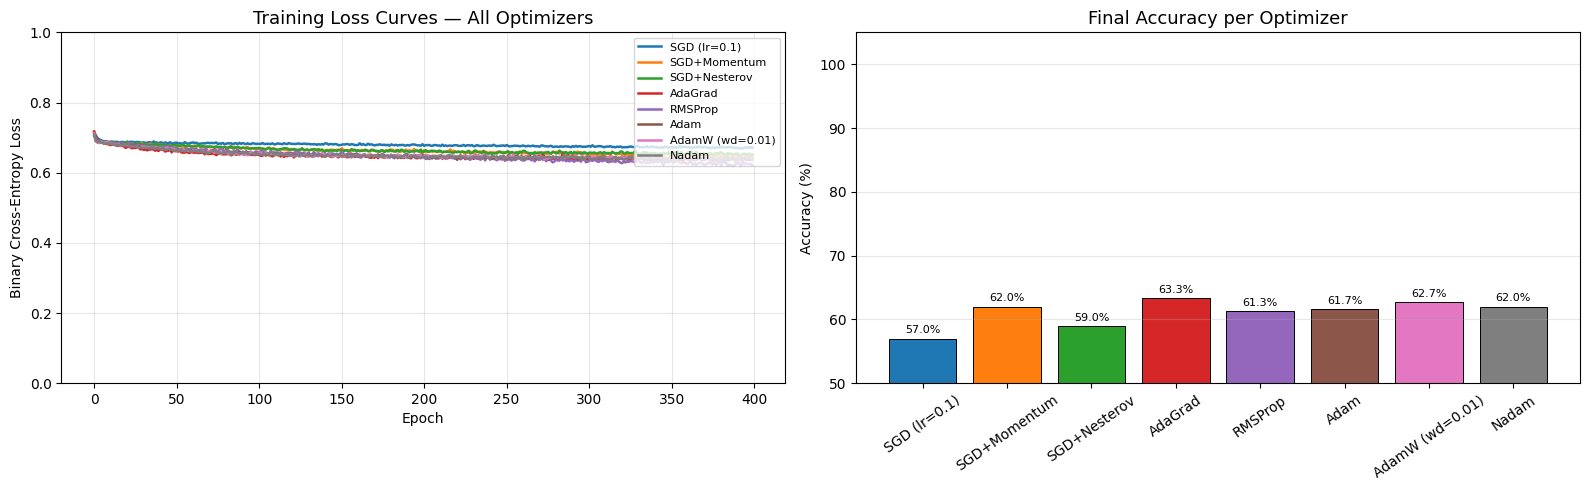


--- Speed to 60% loss reduction ---
  SGD (lr=0.1)               reached 60% reduction at epoch 8
  SGD+Momentum               reached 60% reduction at epoch 55
  SGD+Nesterov               reached 60% reduction at epoch 52
  AdaGrad                    reached 60% reduction at epoch 23
  RMSProp                    reached 60% reduction at epoch 106
  Adam                       reached 60% reduction at epoch 39
  AdamW (wd=0.01)            reached 60% reduction at epoch 40
  Nadam                      reached 60% reduction at epoch 44


In [0]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ---- Define all optimizers ----
optimizers = {
    'SGD (lr=0.1)':            SGD(lr=0.1),
    'SGD+Momentum':            SGDMomentum(lr=0.05, beta=0.9),
    'SGD+Nesterov':            SGDMomentum(lr=0.05, beta=0.9, nesterov=True),
    'AdaGrad':                 AdaGrad(lr=0.1),
    'RMSProp':                 RMSProp(lr=0.01, rho=0.9),
    'Adam':                    Adam(lr=0.01),
    'AdamW (wd=0.01)':         AdamW(lr=0.01, weight_decay=0.01),
    'Nadam':                   Nadam(lr=0.01),
}

results = {}
for name, opt in optimizers.items():
    losses, acc = train(opt, n_epochs=400, batch_size=64)
    results[name] = {'losses': losses, 'acc': acc}
    print(f"{name:<25}  final loss: {losses[-1]:.4f}   accuracy: {acc*100:.1f}%")

# ---- Plot convergence curves ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.tab10.colors
for i, (name, res) in enumerate(results.items()):
    axes[0].plot(res['losses'], label=name, color=colors[i % 10], linewidth=1.8)

axes[0].set_title('Training Loss Curves — All Optimizers', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_ylim(0, 1.0)
axes[0].grid(alpha=0.3)

# ---- Bar chart: final accuracy ----
names  = list(results.keys())
final_accs = [results[n]['acc'] * 100 for n in names]
final_loss = [results[n]['losses'][-1] for n in names]

bars = axes[1].bar(names, final_accs, color=colors[:len(names)], edgecolor='black', linewidth=0.7)
axes[1].set_title('Final Accuracy per Optimizer', fontsize=13)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(50, 105)
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, final_accs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ---- Early convergence comparison (epoch to reach 60% of loss drop) ----
print("\n--- Speed to 60% loss reduction ---")
for name, res in results.items():
    losses = res['losses']
    target = losses[0] - 0.6 * (losses[0] - losses[-1])
    epoch = next((i for i, l in enumerate(losses) if l <= target), len(losses))
    print(f"  {name:<25}  reached 60% reduction at epoch {epoch}")
